In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [3]:
os.listdir('/content/dataset')


['BankChurners.csv']

In [4]:
import pandas as pd

df = pd.read_csv('/content/dataset/BankChurners.csv')

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (10127, 23)

Columns:
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [7]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [8]:
df['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


In [9]:
df['Attrition_Flag'].value_counts(normalize=True) * 100

,proportion
Attrition_Flag,
Existing Customer,83.934038
Attrited Customer,16.065962


In [10]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 Attrition_Flag
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

 Gender
Gender
F    5358
M    4769
Name: count, dtype: int64

 Education_Level
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

 Marital_Status
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

 Income_Category
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

 Card_Category
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,7.080821e+08,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,2.600000e+01,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,1.300000e+01,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1.438300e+03,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.000000e+00,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.000000e+00,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


In [12]:
df['Attrition_Flag'].value_counts(normalize=True) * 100

,proportion
Attrition_Flag,
Existing Customer,83.934038
Attrited Customer,16.065962


In [13]:
df_clean = df.copy()

In [14]:
df_clean = df_clean.drop(columns=[
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

In [15]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (10127, 23)
Cleaned shape: (10127, 20)


In [16]:
X = df_clean.drop(columns=['Attrition_Flag'])
y = df_clean['Attrition_Flag']

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10127, 19)
y shape: (10127,)


In [18]:
y = y.map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

In [19]:
print(y.value_counts())

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64


In [20]:
print(y.unique())

[0 1]


In [21]:
# Check Unknown values in categorical columns

for col in X.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print((X[col] == 'Unknown').sum())


Gender:
0

Education_Level:
1519

Marital_Status:
749

Income_Category:
1112

Card_Category:
0


In [22]:
print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [23]:
X['Avg_Transaction_Amount'] = (
    X['Total_Trans_Amt'] / X['Total_Trans_Ct']
)

In [25]:
X['Transaction_Activity'] = (
    X['Total_Trans_Ct'] / X['Months_on_book']
)

In [27]:
X[['Avg_Transaction_Amount', 'Transaction_Activity']].describe()

,Avg_Transaction_Amount,Transaction_Activity
count,10127.000000,10127.000000
mean,62.612717,1.923120
std,26.404198,0.911977
min,19.137931,0.188679
25%,47.514573,1.272727
50%,55.794872,1.857143
75%,65.476673,2.361111
max,190.193182,9.769231


In [29]:
print("X shape:", X.shape)
X[['Avg_Transaction_Amount', 'Transaction_Activity']].describe()

X shape: (10127, 21)


,Avg_Transaction_Amount,Transaction_Activity
count,10127.000000,10127.000000
mean,62.612717,1.923120
std,26.404198,0.911977
min,19.137931,0.188679
25%,47.514573,1.272727
50%,55.794872,1.857143
75%,65.476673,2.361111
max,190.193182,9.769231


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8101, 21)
Testing data: (2026, 21)


In [32]:
print("Original:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting:")
print(y_test.value_counts(normalize=True) * 100)

Original:
Attrition_Flag
0    83.934038
1    16.065962
Name: proportion, dtype: float64

Training:
Attrition_Flag
0    83.92791
1    16.07209
Name: proportion, dtype: float64

Testing:
Attrition_Flag
0    83.958539
1    16.041461
Name: proportion, dtype: float64


In [33]:
categorical_features = X_train.select_dtypes(
    include='object'
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude='object'
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

Numerical features:
['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Avg_Transaction_Amount', 'Transaction_Activity']


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            categorical_features
        )
    ]
)

In [35]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8101, 21)
Testing data: (2026, 21)


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150,
        random_state=42
    )
}

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_results[name] = {
        metric: scores[f'test_{metric}'].mean()
        for metric in scoring
    }

cv_results

{'Logistic Regression': {'accuracy': np.float64(0.9124803314521595),
  'precision': np.float64(0.7889768612942547),
  'recall': np.float64(0.623698791629826),
  'f1': np.float64(0.6958427387374021),
  'roc_auc': np.float64(0.9333178985348727)},
 'Random Forest': {'accuracy': np.float64(0.9549436790275777),
  'precision': np.float64(0.9336490057959812),
  'recall': np.float64(0.7749778956675508),
  'f1': np.float64(0.8467703405592697),
  'roc_auc': np.float64(0.989686861317975)},
 'Gradient Boosting': {'accuracy': np.float64(0.9682748798562082),
  'precision': np.float64(0.932402799802255),
  'recall': np.float64(0.8656115531977602),
  'f1': np.float64(0.8976637729561009),
  'roc_auc': np.float64(0.991588813948986)}}

In [37]:
import pandas as pd

cv_results_df = pd.DataFrame(cv_results).T

cv_results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.912480,0.788977,0.623699,0.695843,0.933318
Random Forest,0.954944,0.933649,0.774978,0.846770,0.989687
Gradient Boosting,0.968275,0.932403,0.865612,0.897664,0.991589


In [38]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

print("All models trained successfully!")

All models trained successfully!


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.914610,0.816667,0.603077,0.693805,0.931816
1,Random Forest,0.955084,0.950000,0.760000,0.844444,0.988683
2,Gradient Boosting,0.964462,0.950178,0.821538,0.881188,0.991028


In [41]:
best_model_name = test_results_df.loc[
    test_results_df['F1-Score'].idxmax(),
    'Model'
]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


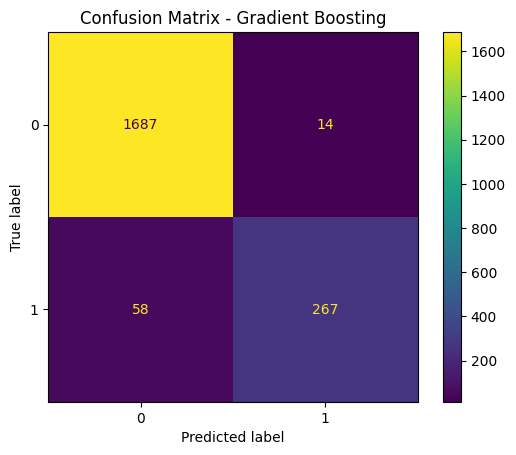

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

<Figure size 800x600 with 0 Axes>

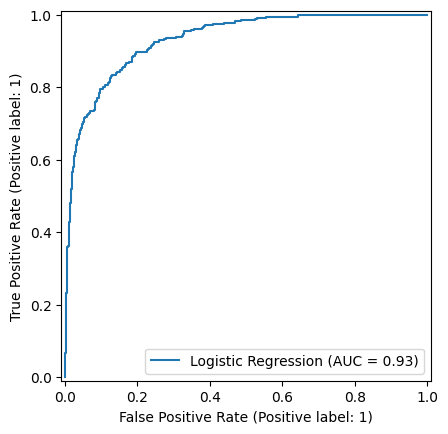

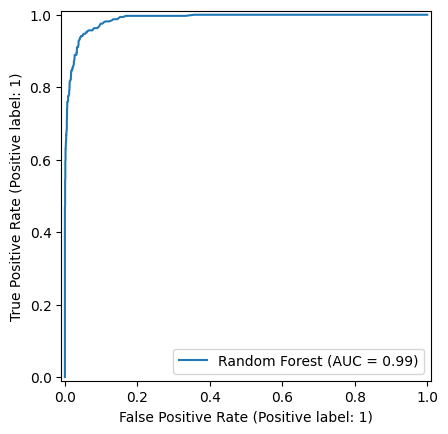

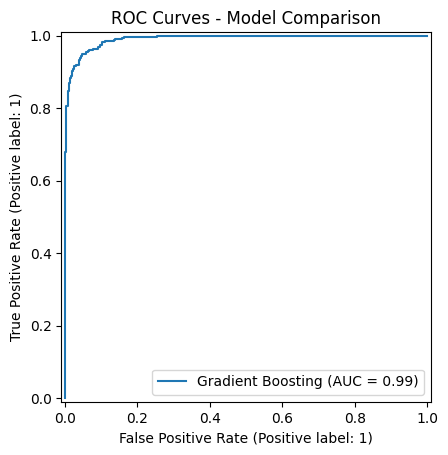

In [44]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.title("ROC Curves - Model Comparison")
plt.show()

In [45]:
test_results_df.sort_values(
    by='F1-Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Gradient Boosting,0.964462,0.950178,0.821538,0.881188,0.991028
1,Random Forest,0.955084,0.950000,0.760000,0.844444,0.988683
0,Logistic Regression,0.914610,0.816667,0.603077,0.693805,0.931816


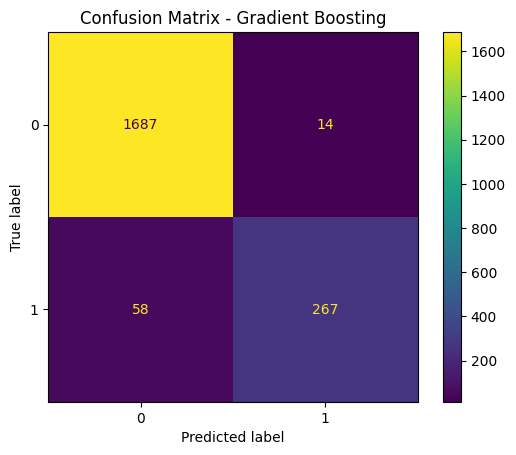

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = trained_models['Gradient Boosting']

y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best
)

plt.title('Confusion Matrix - Gradient Boosting')
plt.show()

In [48]:
import pandas as pd

# Get feature names after preprocessing
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance from Gradient Boosting
importances = best_model.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
11,num__Total_Trans_Ct,0.303007
7,num__Total_Revolving_Bal,0.187543
10,num__Total_Trans_Amt,0.175085
12,num__Total_Ct_Chng_Q4_Q1,0.096195
3,num__Total_Relationship_Count,0.094218
9,num__Total_Amt_Chng_Q4_Q1,0.036924
14,num__Avg_Transaction_Amount,0.036214
15,num__Transaction_Activity,0.020116
5,num__Contacts_Count_12_mon,0.016847
4,num__Months_Inactive_12_mon,0.012351


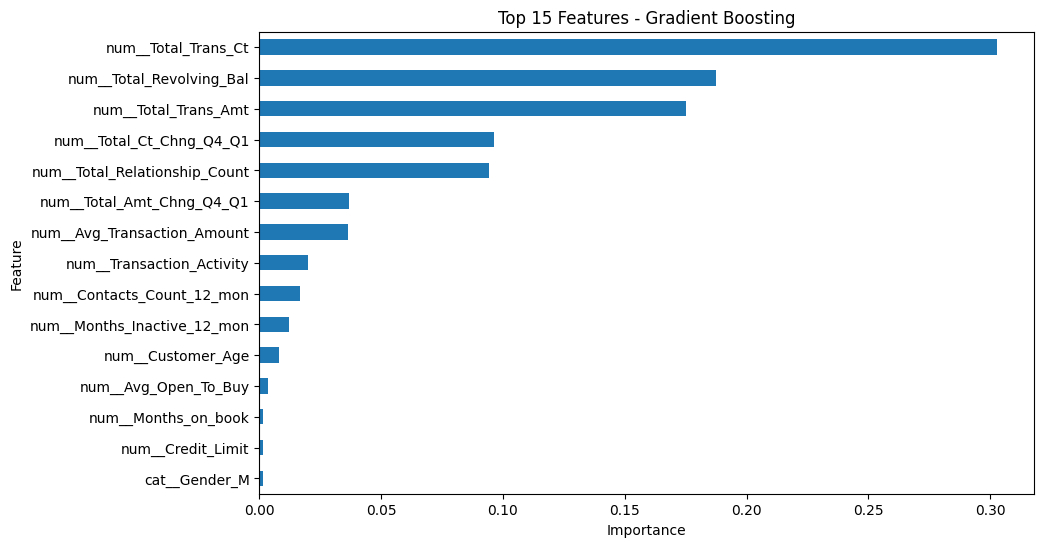

In [49]:
feature_importance.head(15).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10, 6),
    legend=False
)

plt.title('Top 15 Features - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

In [51]:
final_results = test_results_df.copy()

for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    final_results[col] = (
        final_results[col] * 100
    ).round(2)

final_results = final_results.sort_values(
    by='F1-Score',
    ascending=False
)

final_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Gradient Boosting,96.45,95.02,82.15,88.12,99.10
1,Random Forest,95.51,95.00,76.00,84.44,98.87
0,Logistic Regression,91.46,81.67,60.31,69.38,93.18


In [53]:
# -----------------------------------------
# Low-Risk vs High-Risk Customer Demo
# -----------------------------------------

import pandas as pd

# LOW-RISK CUSTOMER
low_risk_customer = pd.DataFrame({
    'Customer_Age': [45],
    'Gender': ['F'],
    'Dependent_count': [2],
    'Education_Level': ['Graduate'],
    'Marital_Status': ['Married'],
    'Income_Category': ['$80K - $120K'],
    'Card_Category': ['Blue'],
    'Months_on_book': [48],
    'Total_Relationship_Count': [5],
    'Months_Inactive_12_mon': [1],
    'Contacts_Count_12_mon': [1],
    'Credit_Limit': [12000],
    'Total_Revolving_Bal': [1800],
    'Avg_Open_To_Buy': [10200],
    'Total_Amt_Chng_Q4_Q1': [1.10],
    'Total_Trans_Amt': [6000],
    'Total_Trans_Ct': [90],
    'Total_Ct_Chng_Q4_Q1': [1.05],
    'Avg_Utilization_Ratio': [0.15],
    'Avg_Transaction_Amount': [6000 / 90],
    'Transaction_Activity': [90 / 48]
})

# HIGH-RISK CUSTOMER
high_risk_customer = pd.DataFrame({
    'Customer_Age': [35],
    'Gender': ['M'],
    'Dependent_count': [2],
    'Education_Level': ['Graduate'],
    'Marital_Status': ['Single'],
    'Income_Category': ['$40K - $60K'],
    'Card_Category': ['Blue'],
    'Months_on_book': [30],
    'Total_Relationship_Count': [2],
    'Months_Inactive_12_mon': [5],
    'Contacts_Count_12_mon': [5],
    'Credit_Limit': [5000],
    'Total_Revolving_Bal': [300],
    'Avg_Open_To_Buy': [4700],
    'Total_Amt_Chng_Q4_Q1': [0.50],
    'Total_Trans_Amt': [1500],
    'Total_Trans_Ct': [20],
    'Total_Ct_Chng_Q4_Q1': [0.45],
    'Avg_Utilization_Ratio': [0.06],
    'Avg_Transaction_Amount': [1500 / 20],
    'Transaction_Activity': [20 / 30]
})

# Make predictions
customers = {
    "Low-Risk Customer": low_risk_customer,
    "High-Risk Customer": high_risk_customer
}

print("========== CUSTOMER CHURN RISK DEMONSTRATION ==========\n")

for customer_type, customer_data in customers.items():

    prediction = best_model.predict(customer_data)[0]
    churn_probability = best_model.predict_proba(customer_data)[0][1]

    print(customer_type)
    print("-" * 40)
    print("Prediction:",
          "Attrited Customer" if prediction == 1 else "Existing Customer")
    print(f"Churn Probability: {churn_probability:.2%}")
    print(f"Retention Probability: {(1 - churn_probability):.2%}")
    print()

========== CUSTOMER CHURN RISK DEMONSTRATION ==========

Low-Risk Customer
----------------------------------------
Prediction: Existing Customer
Churn Probability: 0.71%
Retention Probability: 99.29%

High-Risk Customer
----------------------------------------
Prediction: Attrited Customer
Churn Probability: 91.53%
Retention Probability: 8.47%



<Figure size 600x500 with 0 Axes>

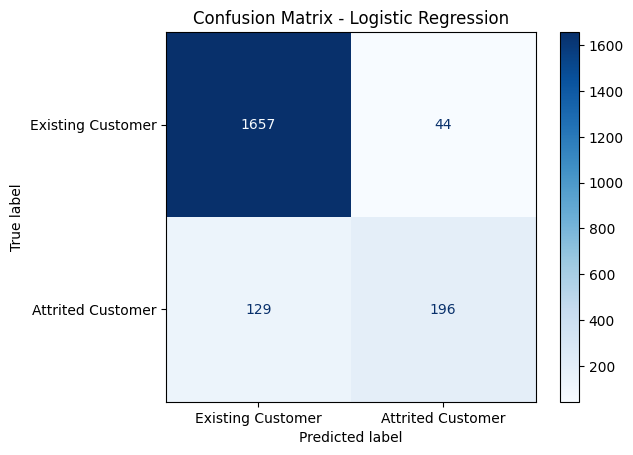

<Figure size 600x500 with 0 Axes>

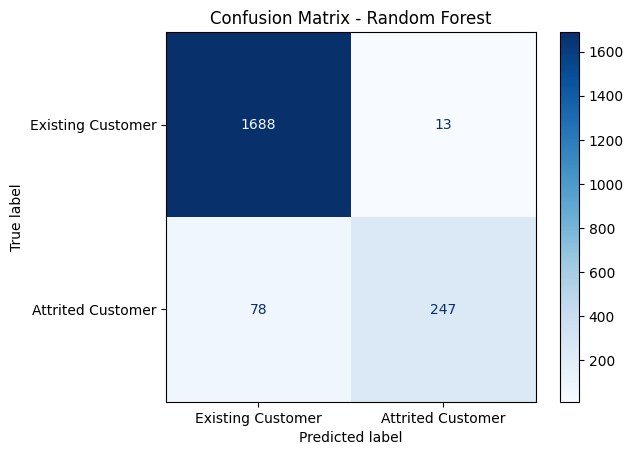

<Figure size 600x500 with 0 Axes>

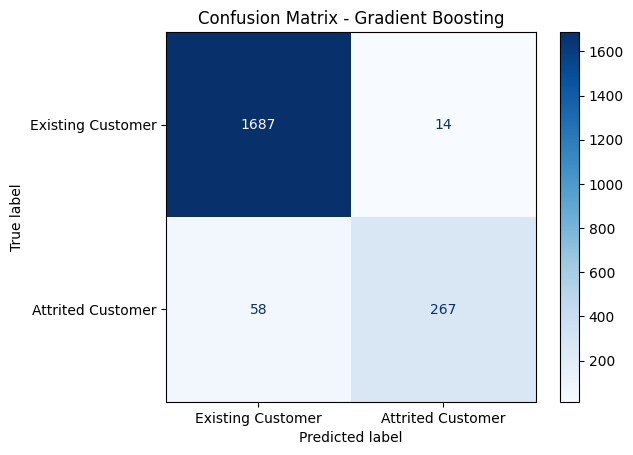

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in trained_models.items():

    plt.figure(figsize=(6, 5))

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=['Existing Customer', 'Attrited Customer'],
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.show()

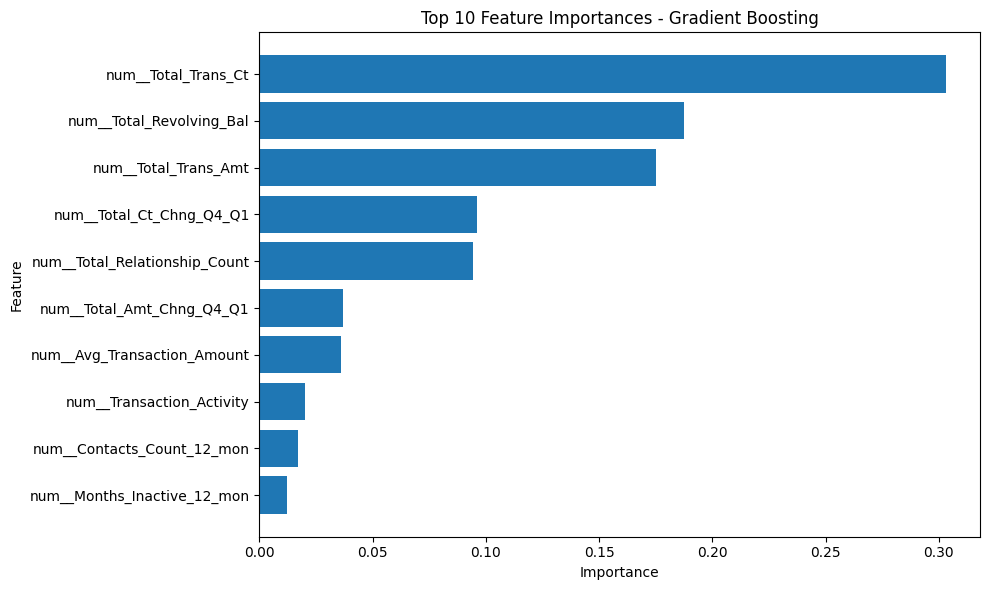

In [55]:
import matplotlib.pyplot as plt

# Select top 10 features
top_features = feature_importance.head(10).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - Gradient Boosting')

plt.tight_layout()
plt.show()